# A Shallow Neural Network for Simple Nonlinear Classification

- Gabriel Wendell Celestino Rocha
---

## Required Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import sklearn
import sklearn.linear_model

def opt_plot():
    # plt.style.use('dark_background')
    plt.grid(True, linestyle = ':', color = '0.50', zorder = 2)
    plt.rcParams['text.usetex'] = True
    plt.rcParams['font.family'] = 'monospace'
    plt.rcParams['font.size'] = 15
    plt.minorticks_on()
    plt.tick_params(axis = 'both', which = 'minor', direction = "in",
                        top = True, right = True, length = 5, width = 1, labelsize = 15)
    plt.tick_params(axis = 'both', which = 'major', direction = "in",
                        top = True, right = True, length = 8, width = 1, labelsize = 15)

---

## Theory

Classification problems are a broad class of machine learning applications devoted to assigning input data to a predefined category based on its features. If the boundary between the categories has a linear relationship to the input data, a simple logistic regression algorithm may do a good job. For more complex groupings, such as in classifying the points in the diagram below, a neural network can often give good results.

In a shallow neural network, the values of the feature vector of the data to be classified (the *input layer*) are passed to a layer of nodes (also known as neurons or units) (the hidden layer) each of which generates a response according to some activation function, $g$, acting on the weighted sum of those values, $z$. The responses of each unit in the hidden layer is then passed to a final, *output layer* (which may consist of a single unit), whose activation produces the classification prediction output.

Identifying the layers with superscript labels $[0]$ (input layer), $[1]$ (hidden layers) and $[3]$ (output layer) so that $a_{j}^{[0]}\equiv x_{j}$ are the input feature values, and $a^{[2]}\equiv\hat{y}$ is the output classification we can write:

$$\tag{1}
z_{j}^{[\ell]}=\sum_{k=1}^{n^{[\ell]}}w_{jk}^{[\ell]}a_{k}^{[\ell-1]}+b_{j}^{[\ell]}\quad;\quad a^{[\ell]}=g^{[\ell]}\left(z_{j}^{[\ell]}\right)\text{ }.
$$

Here, $n^{[\ell]}$ is the number of units in the $\ell^{\text{th}}$ layer. We will consider a binary classification case for which $n^{[2]}=1$.

To train the neural network, it is presented with $m$ training examples, ${\bf x}^{(1)},{\bf x}^{(2)},\ldots,{\bf x}^{(m)}$ corresponding to known classifications $y^{(1)},y^{(2)},\ldots,y^{(m)}$ and the difference between $\hat{y}$ and $y$ (expressed in terms of some cost function) is minimized with respect to the parameters $w_{jk}^{[\ell]}$ and $b_{j}^{[\ell]}$ $(\ell=1,2)$ as with regular logistic regression.

The $m$ column input feature vectors can be packed into a $m\times n^{[0]}$ matrix, ${\bf X}\equiv{\bf A}^{[0]}$, their classifications into a $1\times m$ row vector, ${\bf Y}$, the unit weights into $n^{[\ell]}\times n^{[\ell-1]}$ matrices, ${\bf W}^{[\ell]}$ (for $\ell=1,2$) and the bias constants expressed as $n^{[\ell]}\times 1$ column vectors, ${\bf b}^{[\ell]}$. This allows the above equations to be implemented in matrix algebra as:

$$\tag{2}
\begin{cases}
{\bf Z}^{\left[1\right]}={\bf W}^{\left[1\right]}{\bf A}^{\left[0\right]}+{\bf b}^{\left[1\right]}\text{ }, & {\bf A}^{\left[1\right]}=g^{\left[1\right]}\left({\bf Z}^{\left[1\right]}\right)\text{ },\\
{\bf Z}^{\left[2\right]}={\bf W}^{\left[2\right]}{\bf A}^{\left[1\right]}+{\bf b}^{\left[2\right]}\text{ }, & \hat{{\bf y}}={\bf A}^{\left[2\right]}=g^{\left[2\right]}\left({\bf Z}^{\left[2\right]}\right)\text{ },
\end{cases}\text{ }.
$$

There are many nonlinear response functions to choose for $g^{[\ell]}$, including the logistic function, $\sigma(z)=\left(1+e^{-z}\right)^{-1}$, the closely-related hyperbolic tangent function, $\tanh{(x)}$, and the rectified linear unit (ReLU) function, $x^{+}=\max\left(0,x\right)$.

## The Code

The code below implements a shallow neural network to classify the points in the file [`pts.txt`](https://github.com/GabrielWendell/Math-ML_Minicouse/blob/main/Notebooks/Examples/Data/pts.txt). Progress in training the algorithm is animated by plotting the decision boundary for the set of parameters ${\bf W}^{[\ell]}$ and ${\bf b}^{[\ell]}$ at each $100^{\text{th}}$ iteration of the cost function minimization.

iteration 0 : J = 0.6931239329074416
iteration 100 : J = 0.654191434234015
iteration 200 : J = 0.6539824235863124
iteration 300 : J = 0.6539370296224055
iteration 400 : J = 0.6538730820211748
iteration 500 : J = 0.6537538619580845
iteration 600 : J = 0.6534731605169356
iteration 700 : J = 0.6503881474137589
iteration 800 : J = 0.5038243900542234
iteration 900 : J = 0.5088204025481382
iteration 1000 : J = 0.39874220218489204
iteration 1100 : J = 0.35845862808235895
iteration 1200 : J = 0.35054005375584435
iteration 1300 : J = 0.3282328804294586
iteration 1400 : J = 0.3013980847004183
iteration 1500 : J = 0.28643673505271955
iteration 1600 : J = 0.28166448716894094
iteration 1700 : J = 0.2756034161614773
iteration 1800 : J = 0.26972113174009904
iteration 1900 : J = 0.26461428763995554
iteration 2000 : J = 0.2605670407991595
iteration 2100 : J = 0.2574376420448055
iteration 2200 : J = 0.2549397545079143
iteration 2300 : J = 0.2528380927381724
iteration 2400 : J = 0.2509844461093659
iterat

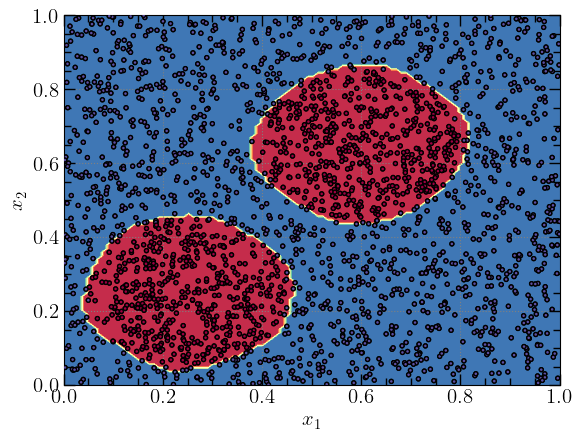

In [3]:
# Training rate.
alpha = 2

# Load the points and ensure shapes are X: (2, m) and Y: (1, m).
pts = np.loadtxt('Data/pts.txt')
X, Y = pts[:,:2].T, pts[:,2][None, :]

# Number of feature vector components (should be 2!).
n0 = X.shape[0]
# Number of training examples.
m = X.shape[1]

# Number of hidden layer units.
n1 = 16
# Number of output units.
n2 = 1

# Activation function for the hidden layer: hyperbolic tan.
g1 = np.tanh
# Activation function for the output layer: logistic function.
def g2(Z):
    return 1 / (1 + np.exp(-Z))

def predictions(X, W1, b1, W2, b2):
    """
    Return the predictions, A2 (and various intermediate quantities for
    caching) for the parameters W1, b1, W2, b2 on the input matrix, X.
    """

    Z1 = W1 @ X + b1
    A1 = g1(Z1)
    Z2 = W2 @ A1 + b2
    A2 = g2(Z2)
    return Z1, A1, Z2, A2

def cost(Yhat, Y):
    """Evaluate and return the cost function J(Yhat, Y)."""
    return -np.sum(Y * np.log(Yhat) + (1 - Y) * np.log(1 - Yhat)) / m

def backprop(A1, Z1, A2, Z2, W1, b1, W2, b2):
    """Backpropagation to update the fit parameters."""

    # The derivatives of the cost function with respect to the various
    # quantities, dJ/dQ are assigned to variables named dQ.

    # For g2 = sigmoid logistic function.
    dZ2 = A2 - Y
    dW2 = dZ2 @ A1.T / m
    db2 = np.sum(dZ2, axis = 1, keepdims = True) / m
    # For g1 = tanh activation function.
    dZ1 = W2.T @ dZ2 * (1 - A1**2)
    dW1 = dZ1 @ X.T / m
    db1 = np.sum(dZ1, axis = 1, keepdims = True) / m

    W1 -= alpha * dW1
    b1 -= alpha * db1
    W2 -= alpha * dW2
    b2 -= alpha * db2
    return W1, b1, W2, b2

def initialize_params():
    """Randomly initialize the W coefficients, initialize the biases to zero."""
    W1 = np.random.randn(n1, n0) * 0.01
    b1 = np.zeros((n1, 1))
    W2 = np.random.randn(n2, n1) * 0.01
    b2 = np.zeros((n2, 1))
    return W1, b1, W2, b2

def plot_decision_boundary(X, y, params):
    """Plot the decision boundary for prediction trained on X, y."""

    # Set min and max values and give it some padding.
    x_min, x_max = X[0, :].min() - 0.1, X[0, :].max() + 0.1
    y_min, y_max = X[1, :].min() - 0.1, X[1, :].max() + 0.1
    h = 0.01
    # Generate a meshgrid of points with orthogonal spacing.
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    # Prediction of the classified values across the whole grid.
    Z = np.round(predictions(np.c_[xx.ravel(), yy.ravel()].T, *params)[-1])
    Z = Z.reshape(xx.shape)
    # Plot the decision boundary as a contour plot and training examples.
    plt.contourf(xx, yy, Z, cmap = plt.cm.Spectral)
    plt.scatter(X[0, :], X[1, :], c = y, cmap = plt.cm.Spectral, s = 8, edgecolor = 'black', zorder = 3)
    plt.ylabel('$x_2$')
    plt.xlabel('$x_1$')

def train(X, Y, max_it = 1000):
    """Train the neural network on the features X classified as Y."""

    W1, b1, W2, b2 = initialize_params()

    for it in range(max_it):
        Z1, A1, Z2, A2 = predictions(X, W1, b1, W2, b2)
        J = cost(A2, Y)
        W1, b1, W2, b2 = backprop(A1, Z1, A2, Z2, W1, b1, W2, b2)
        if not it % 100:
            # Provide an update on the progress we have made so far.
            print('iteration {} : J = {}'.format(it, J))
            # Clear the current figure and redraw with the latest prediction.
            plt.clf()
            plot_decision_boundary(X, Y, (W1, b1, W2, b2))
            plt.xlim(0,1)
            plt.ylim(0,1)
            opt_plot()
            plt.savefig('Plots/frames/{:05d}.png'.format(it))

    return W1, b1, W2, b2

W1, b1, W2, b2 = train(X, Y, 7000)

plot_decision_boundary(X, Y, (W1, b1, W2, b2))
plt.xlim(0,1)
plt.ylim(0,1)
opt_plot()
plt.show()

**OBS:** The frames of the animation are saved as PNG image files to the directory `frames/`.

---